In [1]:
!pip install matplotlib numpy ipywidgets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import ipywidgets as widgets
from IPython.display import display

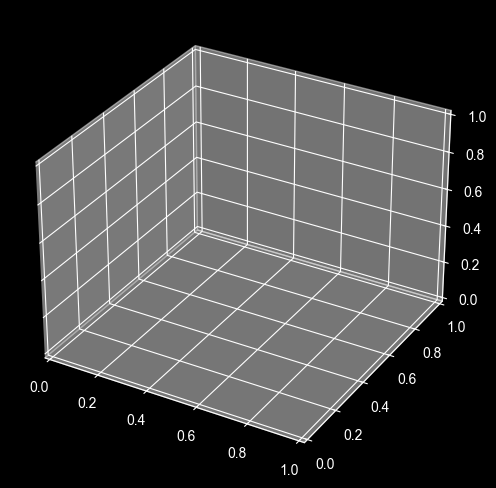

In [3]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Sphere layers
def draw_sphere(radius, color, alpha):
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    x = radius * np.outer(np.cos(u), np.sin(v))
    y = radius * np.outer(np.sin(u), np.sin(v))
    z = radius * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(x, y, z, color=color, alpha=alpha)

def update(angle):
    ax.clear()
    ax.set_facecolor("black")
    draw_sphere(3, "blue", 0.3)
    draw_sphere(2, "orange", 0.5)
    draw_sphere(1, "red", 0.9)
    ax.view_init(30, angle)
    ax.set_axis_off()

ani = FuncAnimation(fig, update, frames=range(0,360,5), interval=100)
plt.show()

C:\Users\cyber\PyCharmMiscProject\.venv\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


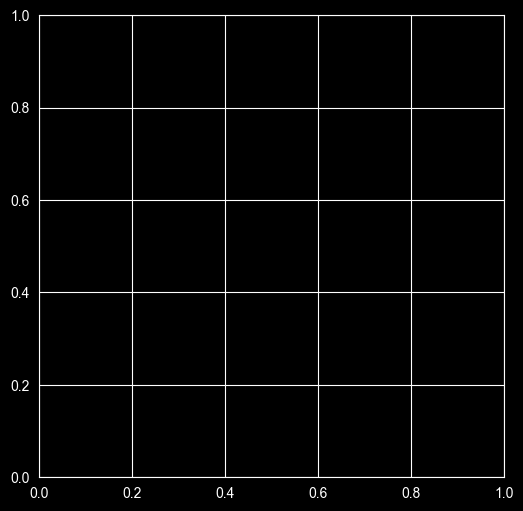

In [4]:
fig, ax = plt.subplots(figsize=(6,6))
fig.patch.set_facecolor('black')

layers = [
    (150, "blue"),
    (100, "orange"),
    (50, "red")
]

def animate(i):
    ax.clear()
    ax.set_facecolor("black")

    for r, c in layers:
        circle = plt.Circle((0,0), r, color=c, alpha=0.7)
        ax.add_patch(circle)

    # rotating cut line
    angle = np.radians(i)
    x = [0, 160*np.cos(angle)]
    y = [0, 160*np.sin(angle)]
    ax.plot(x, y, color="white", lw=2)

    ax.set_xlim(-170,170)
    ax.set_ylim(-170,170)
    ax.set_aspect('equal')
    ax.axis('off')

ani = FuncAnimation(fig, animate, frames=360, interval=50)
plt.show()

In [5]:
def plot_layers(crust=True, mantle=True, core=True):
    fig, ax = plt.subplots(figsize=(6,6))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('black')

    if crust:
        ax.add_patch(plt.Circle((0,0),150,color='blue'))
    if mantle:
        ax.add_patch(plt.Circle((0,0),100,color='orange'))
    if core:
        ax.add_patch(plt.Circle((0,0),50,color='red'))

    ax.set_xlim(-170,170)
    ax.set_ylim(-170,170)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.show()

widgets.interact(plot_layers,
                 crust=True,
                 mantle=True,
                 core=True)

interactive(children=(Checkbox(value=True, description='crust'), Checkbox(value=True, description='mantle'), C…

<function __main__.plot_layers(crust=True, mantle=True, core=True)>

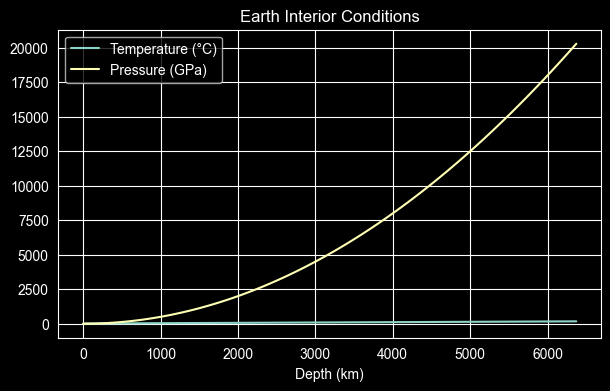

In [6]:
depth = np.linspace(0, 6371, 100)  # km

# Approx trends
temperature = 15 + 0.025 * depth
pressure = 1 + 0.0005 * depth**2

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(depth, temperature, label="Temperature (°C)")
ax.plot(depth, pressure, label="Pressure (GPa)")

ax.set_xlabel("Depth (km)")
ax.set_title("Earth Interior Conditions")
ax.legend()
plt.show()